# Importing necessary libraries

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from scipy.stats import kurtosis 


# Function definitions

In [2]:
def simple_ica_clean(raw, n_components=15):
    """
    Simple ICA cleaning without topography requirements
    Returns cleaned raw object and the ICA object
    """
    # Pick only EEG channels
    raw_eeg = raw.copy().pick_types(eeg=True)
    
    # Fit ICA (no montage needed)
    ica = ICA(n_components=n_components, random_state=42)
    ica.fit(raw_eeg)
    
    # Auto-detect artifacts using kurtosis
    sources = ica.get_sources(raw_eeg).get_data()
    kurt_values = kurtosis(sources, axis=1, fisher=True)
    exclude = np.where(kurt_values > np.percentile(kurt_values, 75))[0]
    print(f"Excluding components: {exclude}")
    
    # Apply cleaning
    raw_cleaned = raw.copy()
    ica.apply(raw_cleaned, exclude=exclude)
    
    return raw_cleaned, ica

In [3]:
def apply_ica_artifact_removal(raw, channel_name, n_components=15, method='fastica', max_iter=200,
                              start_time=0, stop_time=10, random_state=42):
    """
    Apply ICA to remove artifacts from EEG data and extract one channel.

    Parameters:
    - raw: MNE Raw object
    - channel_name: str, name of the channel to extract
    - n_components: int, number of ICA components
    - method: str, ICA method ('fastica', 'picard', or 'infomax')
    - max_iter: int, maximum iterations for ICA
    - start_time: float, start time in seconds
    - stop_time: float, stop time in seconds
    - random_state: int, seed for reproducibility

    Returns:
    - data: NumPy array, original data
    - cleaned_data: NumPy array, data after ICA artifact removal
    - times: NumPy array, time points
    """
    # Convert time to samples
    start_sample = int(start_time * raw.info['sfreq'])
    stop_sample = int(stop_time * raw.info['sfreq'])

    # Handle duplicate channel names
    if channel_name not in raw.ch_names:
        # Try appending '-1' for duplicate channels (e.g., 'T8-P8' -> 'T8-P8-1')
        channel_name_adjusted = f"{channel_name}-1"
        if channel_name_adjusted in raw.ch_names:
            print(f"Adjusted channel name from {channel_name} to {channel_name_adjusted}")
            channel_name = channel_name_adjusted
        else:
            raise ValueError(f"Channel {channel_name} not found in raw.ch_names: {raw.ch_names}")

    # Extract original data for the selected channel
    data, times = raw[channel_name, start_sample:stop_sample]
    data = data[0]  # Shape: (n_samples,)
    times = times  # Shape: (n_samples,)

    # Apply ICA to all EEG channels
    ica = ICA(n_components=n_components, method=method, max_iter=max_iter, random_state=random_state)
    ica.fit(raw.copy().pick_types(eeg=True))  # Fit ICA on EEG channels

    # Get ICA component time series (scores)
    sources = ica.get_sources(raw).get_data()

    # Automatically identify artifact components based on kurtosis
    kurt_values = kurtosis(sources, axis=1, fisher=True)  # Compute kurtosis for each component
    exclude = np.where(kurt_values > np.percentile(kurt_values, 75))[0]  # Exclude top 25% kurtosis components
    print(f"Excluding ICA components: {exclude}")

    # Apply ICA to reconstruct cleaned data
    raw_cleaned = raw.copy()
    ica.apply(raw_cleaned, exclude=exclude)

    # Extract cleaned data for the selected channel
    cleaned_data, _ = raw_cleaned[channel_name, start_sample:stop_sample]
    cleaned_data = cleaned_data[0]  # Shape: (n_samples,)

    return data, cleaned_data, times


In [4]:
def apply_fir_bandpass_filter(raw, channel_name, lowcut, highcut, start_time=0, stop_time=10):
    """
    Apply an FIR bandpass filter to a single channel of raw data.
    
    Parameters:
    - raw: MNE Raw object
    - channel_name: str, name of the channel to filter
    - lowcut: float, lower frequency bound (Hz)
    - highcut: float, upper frequency bound (Hz)
    - start_time: float, start time in seconds
    - stop_time: float, stop time in seconds
    
    Returns:
    - data: NumPy array, original data
    - filtered_data: NumPy array, filtered data
    - times: NumPy array, time points
    """
    # Convert time to samples
    start_sample = int(start_time * raw.info['sfreq'])
    stop_sample = int(stop_time * raw.info['sfreq'])
    
    # Extract original data
    data, times = raw[channel_name, start_sample:stop_sample]
    data = data[0]  # Shape: (n_samples,)
    times = times  # Shape: (n_samples,)
    
    # Apply FIR bandpass filter
    raw_filtered = raw.copy().filter(l_freq=lowcut, h_freq=highcut, picks=[channel_name], 
                                    method='fir', phase='zero', fir_design='firwin')
    filtered_data, _ = raw_filtered[channel_name, start_sample:stop_sample]
    filtered_data = filtered_data[0]  # Shape: (n_samples,)
    
    return data, filtered_data, times



# Raw data visualization plot

Extracting EDF parameters from /home/nicko/implementations/THESIS/main-thesis-folder/physionet.org/files/chbmit/1.0.0/chb02/chb02_16.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


<ipython-input-5-64d59e0ae1d8>:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_file, preload=True)


Reading 0 ... 245503  =      0.000 ...   958.996 secs...
Plot all channels
Using matplotlib as 2D backend.


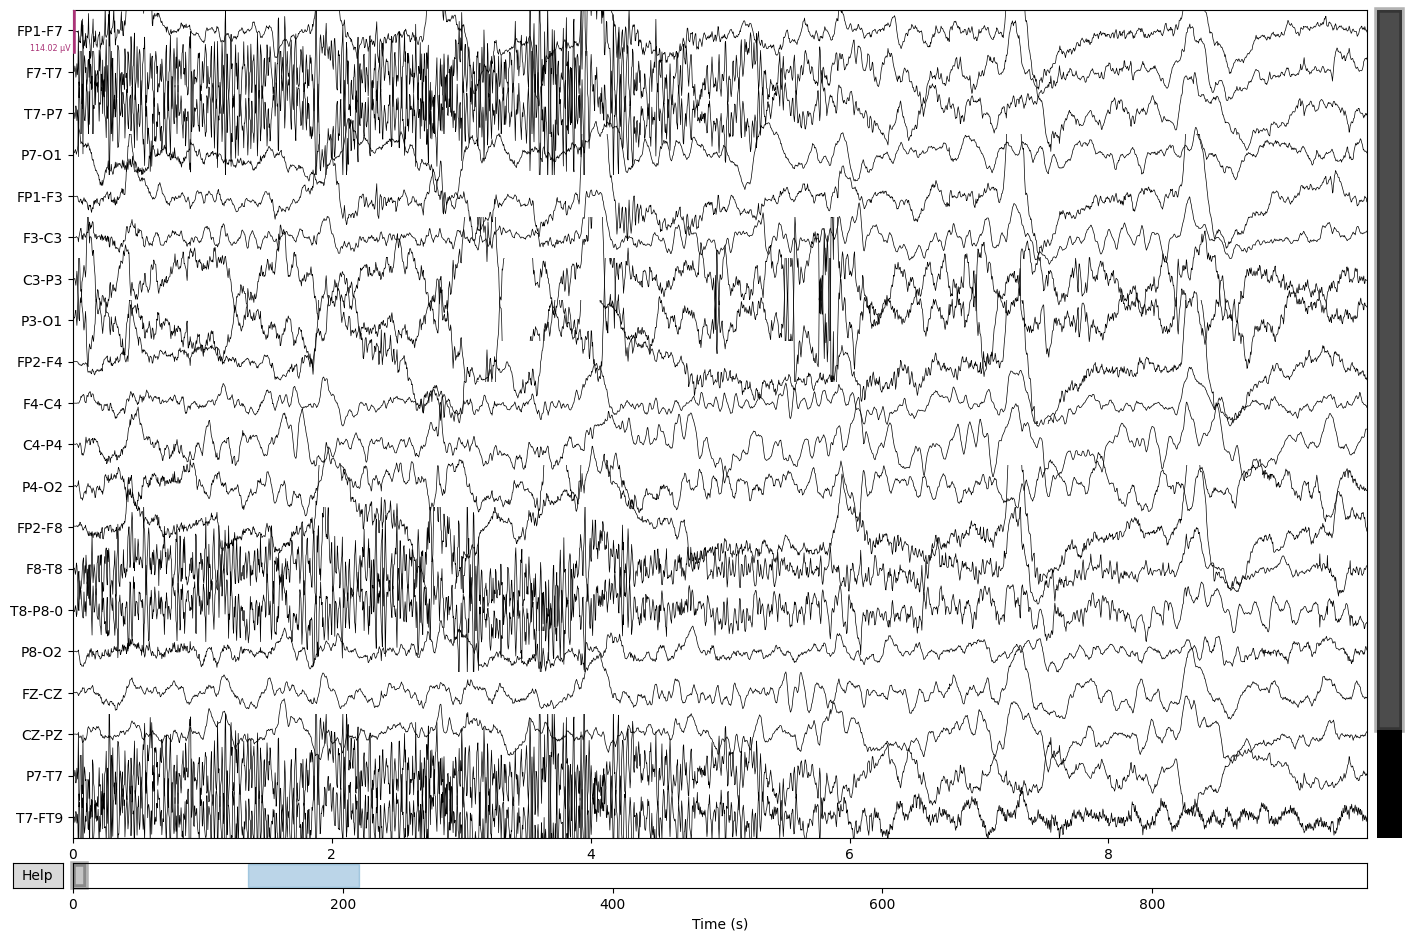

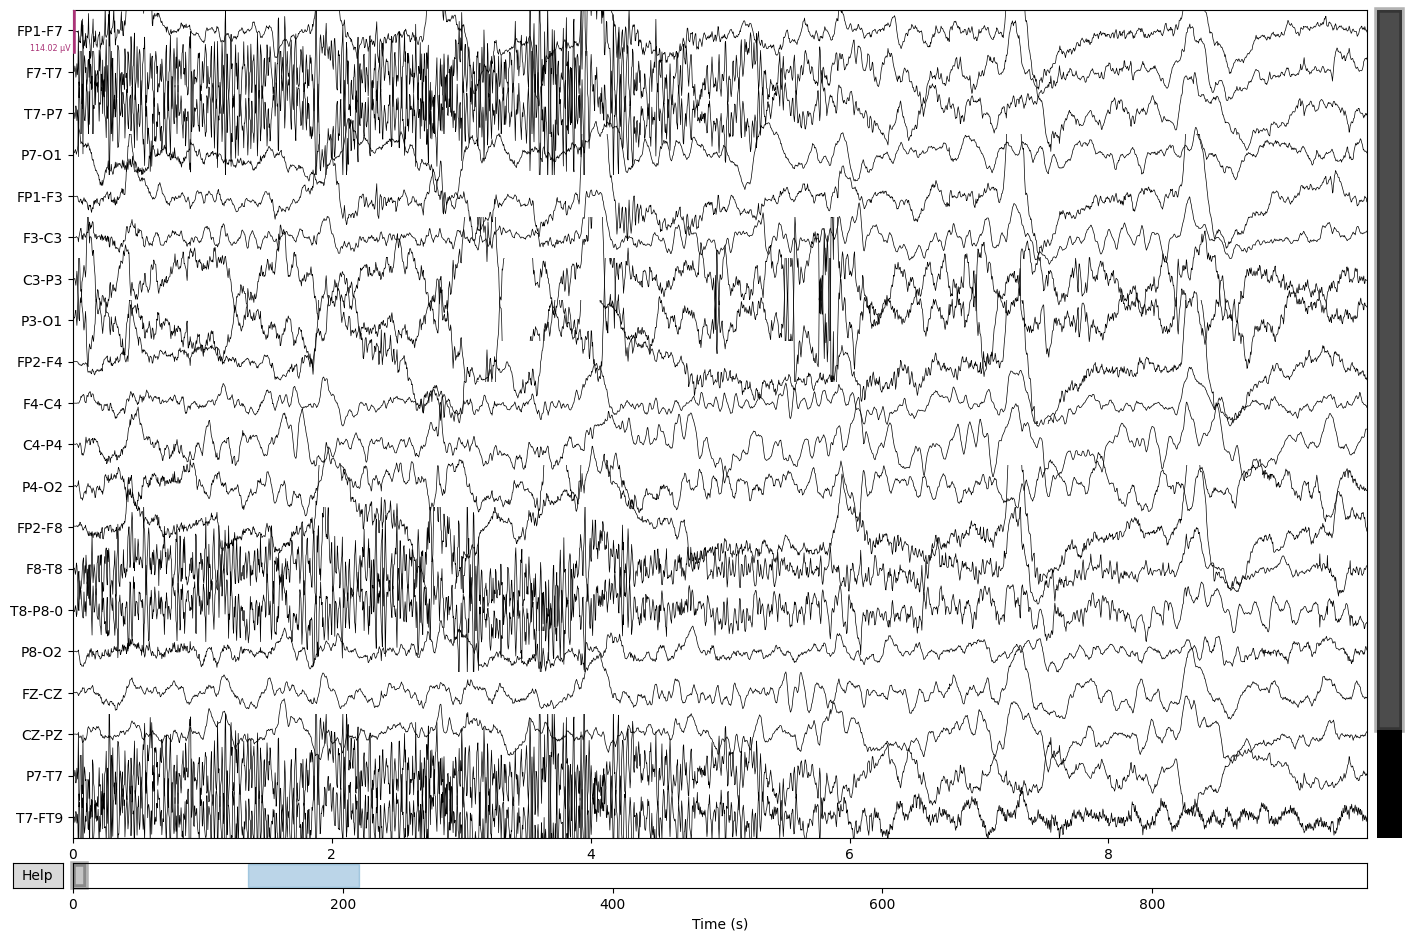

In [5]:
edf_file="/home/nicko/implementations/THESIS/main-thesis-folder/physionet.org/files/chbmit/1.0.0/chb02/chb02_16.edf"



### annotation of the epileptic seizure and plot
seizure_start = 130  # seconds
seizure_end = 212     # secondsonset = [seizure_start]  # Time of event start
onset=[seizure_start]
raw = mne.io.read_raw_edf(edf_file, preload=True)

duration = [seizure_end - seizure_start]  # Duration of event
description = ['Epileptic Seizure']  # Label

annotations = mne.Annotations(onset=onset, duration=duration, description=description)# Add annotations
raw.set_annotations(annotations)

print("Plot all channels")
raw.plot(scalings='auto', title='EEG Channels with Seizure Event', show=True, block=True)


# Bandpass filter & visualization

Extracting EDF parameters from /home/nicko/implementations/THESIS/main-thesis-folder/physionet.org/files/chbmit/1.0.0/chb02/chb02_16.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 245503  =      0.000 ...   958.996 secs...
Selected channel: FP1-F7
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4.5 - 40 Hz



<ipython-input-6-4e4de861a893>:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_file, preload=True)


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.50
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (1.652 s)

Extracted 2560 samples from 0 to 10 seconds
Shape of data: (2560,), Shape of times: (2560,), Shape of filtered_data: (2560,)
Generating plot...


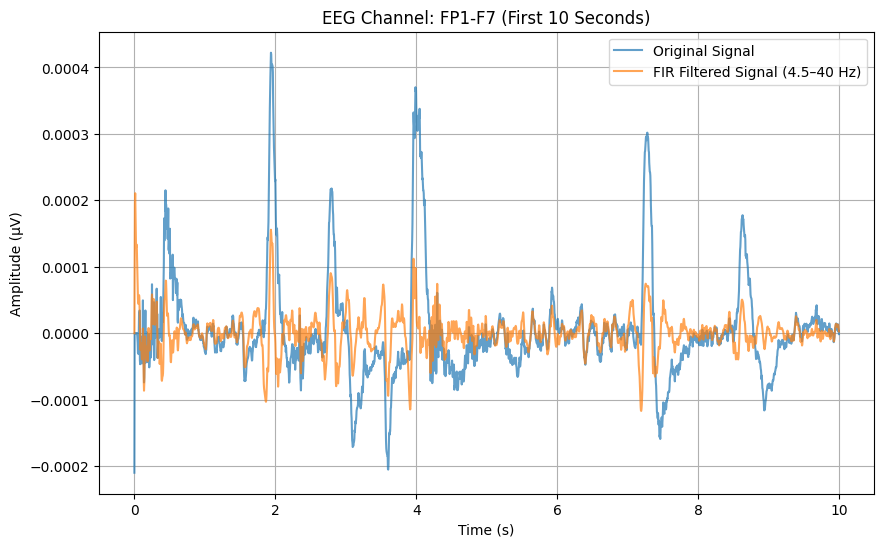

In [6]:
### Pass a single channel via a bandpass filter and visualize
# Read the EDF file
raw = mne.io.read_raw_edf(edf_file, preload=True)
# Select the first channel
channel_name = raw.ch_names[0]  # First channel
print(f"Selected channel: {channel_name}")
# Define initial filter parameters
lowcut = 4.5  # Hz
highcut = 40  # Hz

# Apply filter and get data
data, filtered_data, times = apply_fir_bandpass_filter(raw, channel_name, lowcut, highcut)

print(f"Extracted {len(data)} samples from 0 to 10 seconds")
print(f"Shape of data: {data.shape}, Shape of times: {times.shape}, Shape of filtered_data: {filtered_data.shape}")

print("Generating plot...")

# Plot original and filtered signals
plt.figure(figsize=(10, 6))
plt.plot(times, data, label='Original Signal', alpha=0.7)
plt.plot(times, filtered_data, label=f'FIR Filtered Signal ({lowcut}–{highcut} Hz)', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title(f'EEG Channel: {channel_name} (First 10 Seconds)')
plt.legend()
plt.grid(True)
plt.show()
